In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def f(t,y):
    return t*np.exp(t*3) - 2*y

def real_f(t):
    return (1/5)*t*np.exp(3*t) - (1/25)*np.exp(3*t) + (1/25)*np.exp(-2*t)


def adams2(y0,h,ti,tf,f,real_f):
    N = int(np.ceil((tf-ti)/h))
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    y[0],y[1]= y0,real_f(ti + h)
    t[1] = t[0] + h
    for i in range(1,N):
        t[i + 1] = t[i] + h
        y[i + 1] = y[i] + (h/2)*(3*f(t[i],y[i]) - f(t[i - 1], y[i - 1]))

    return t,y

def adams3(y0,h,ti,tf,f,real_f):
    N = int(np.ceil((tf-ti)/h))
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    y[0],y[1],y[2]= y0,real_f(ti + h),real_f(ti + 2*h)
    t[1],t[2] = t[0] + h, t[0] + 2*h
    for i in range(2,N):
        t[i + 1] = t[i] + h
        y[i + 1] = y[i] + (h/12)*(23*f(t[i],y[i]) - 16*f(t[i - 1], y[i - 1]) + 5*f(t[i - 2],y[i - 2]))

    return t,y

def adams4(y0,h,ti,tf,f,real_f):
    N = int(np.ceil((tf-ti)/h))
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    y[0],y[1],y[2],y[3]= y0,real_f(ti + h),real_f(ti + 2*h), real_f(ti + 3*h)
    t[1],t[2],t[3] = t[0] + h, t[0] + 2*h, t[0] + 3*h
    for i in range(3,N):
        t[i + 1] = t[i] + h
        y[i + 1] = y[i] + (h/24)*(55*f(t[i],y[i]) - 59*f(t[i - 1], y[i - 1]) + 37*f(t[i - 2],y[i - 2]) - 9*f(t[i - 3],y[i-3]))

    return t,y



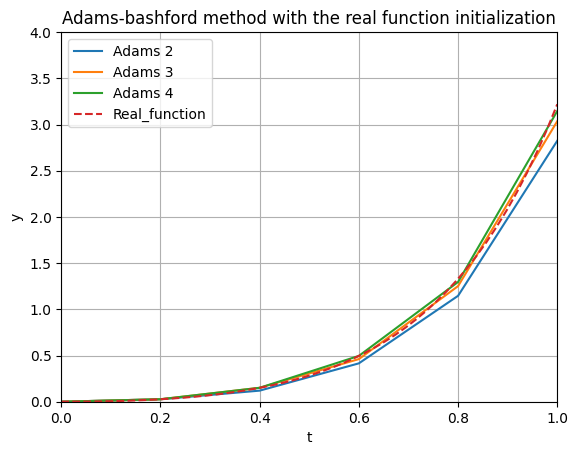

In [7]:
t_2,y_2 = adams2(0,0.2,0,1,f,real_f)
t_3,y_3 = adams3(0,0.2,0,1,f,real_f)
t_4,y_4 = adams4(0,0.2,0,1,f,real_f)
t_real = np.linspace(0,1)
plt.plot(t_2,y_2, label = "Adams 2")
plt.plot(t_3,y_3, label = "Adams 3")
plt.plot(t_4,y_4, label = "Adams 4")
plt.plot(t_real,real_f(t_real), linestyle = '--',label = "Real_function")
plt.xlabel("t")
plt.ylabel("y")
plt.axis([0,1,0,4])
plt.title("Adams-bashford method with the real function initialization")
plt.savefig("Adams-bashford real init")
plt.legend()
plt.grid()
plt.show()